In [ ]:
!pip install datasets
!pip install torch
!pip install transformers
!pip install pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.


In [ ]:
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("smartcat/Amazon_Clothing_Shoes_and_Jewelry_2023", split="train")

# Display the first record
print(dataset[0])

README.md:   0%|          | 0.00/8.12k [00:00<?, ?B/s]

train-00000-of-00013.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

train-00001-of-00013.parquet:   0%|          | 0.00/202M [00:00<?, ?B/s]

train-00002-of-00013.parquet:   0%|          | 0.00/201M [00:00<?, ?B/s]

train-00003-of-00013.parquet:   0%|          | 0.00/198M [00:00<?, ?B/s]

...

train-00010-of-00013.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

train-00011-of-00013.parquet:   0%|          | 0.00/193M [00:00<?, ?B/s]

train-00012-of-00013.parquet:   0%|          | 0.00/192M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2539634 [00:00<?, ? examples/s]

{'main_category': 'AMAZON FASHION', 'title': "SAS Women's, Relaxed Sandal", 'average_rating': 4.7, 'rating_number': 618, 'features': 'Made in the USA\nSuede sole\nHeel measures approximately 1.5 inches"\nCOMFY FOOTWEAR: Unwind, leave your worries behind, and simply relax and enjoy the comfort of the versatile SAS Relaxed sandal with pemium leather uppers in a casual sandal silhouette\nCUSHION LININGS: It features Ultra-Puff cushioned linings that protect the foot with Super Soft topline construction eliminating harsh edges against the foot\nSHOCK ABSORPTION: A broad, contoured footbed features soft Super Suede linings that molds to the natural arches and curves of your foot for maximum comfort and shock absorption\nQUALITY BUILD: It offers multi-layered Tripad cushions designed to comfort all three pressure points: the inside ball, outside ball and heel for all-day support\nADJUSTABLE CLOSURE: SAS sandal features three-point adjustability with durable buckles at each strap while a shoc

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json

# Modified transform function to extract specific fields and filter brands
def transform(record):
    # Extract brand from the 'store' field
    brand = record.get('store', '')
    if brand is None:
        return None
    brand = brand.strip()

    # Check if brand is in the excluded brands list (case insensitive)
    included_brands = ["nike", "adidas", "puma", "levi's", "jockey", "tommy hilfiger", "louis vuitton", "gucci"]
    if brand.lower() not in included_brands:
        return None

    # Extract title and large image URL
    title = record.get('title', '').strip()
    images = record.get('images', [])
    large_image_url = images[0].get('large') if images else None

    if title and brand and large_image_url:
        return {
            "title": title,
            "brand": brand,
            "image": large_image_url
        }
    return None

# Apply the transformation
filtered_data = [
    transform(record) for record in dataset
    if transform(record) is not None
]

# Save the filtered dataset as a JSON file
output_path = "/content/drive/My Drive/filtered_dataset_amazon_fashion.json"
with open(output_path, "w") as json_file:
    json.dump(filtered_data, json_file, indent=4)

print(f"Filtered dataset has been saved to {output_path}")

Filtered dataset has been saved to /content/drive/My Drive/filtered_dataset_amazon_fashion.json


In [ ]:
print(f"Length: {len(filtered_data)}")
print(filtered_data[0])

In [ ]:
from transformers import CLIPProcessor, CLIPModel
import torch
import pickle
from PIL import Image
import os
import json
import requests
from io import BytesIO

# Path to the new filtered dataset JSON file
filtered_dataset_path = "/content/drive/My Drive/filtered_dataset_amazon_fashion.json"

# Load the new filtered dataset
with open(filtered_dataset_path, "r") as f:
    filtered_data = json.load(f)

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# Helper function to fetch image from URL
def fetch_image_from_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert("RGB")
        return image
    except Exception as e:
        print(f"Error fetching image from URL {url}: {e}")
        return None

# Compute embeddings and store metadata
embeddings = []
metadata = []

for i in range(1000,7000):
    record = filtered_data[i]
    image_url = record.get("image", "")
    if image_url:
        try:
            # Fetch the image from the URL
            image = fetch_image_from_url(image_url)
            if image is None:
                continue

            # Prepare the image for the model
            inputs = processor(images=image, return_tensors="pt")
            with torch.no_grad():
                embedding = model.get_image_features(**inputs).squeeze().numpy()

            # Store the embedding and metadata
            embeddings.append(embedding)
            metadata.append({
                "title": record.get("title", ""),
                "brand": record.get("brand", ""),
                "image": image_url
            })
        except Exception as e:
            print(f"Error processing image: {e}")

# Save embeddings and metadata as a pickle file
output_pickle_path = "/content/drive/My Drive/image_embeddings_amazon_fashion.pkl"

# Check if the pickle file exists
if os.path.exists(output_pickle_path):
    # Load existing data
    with open(output_pickle_path, "rb") as f:
        existing_data = pickle.load(f)
    existing_embeddings = existing_data.get("embeddings", [])
    existing_metadata = existing_data.get("metadata", [])
else:
    # Initialize empty data if the file doesn't exist
    existing_embeddings = []
    existing_metadata = []

# Append new embeddings and metadata
combined_embeddings = existing_embeddings + embeddings
combined_metadata = existing_metadata + metadata

# Save the updated data back to the pickle file
with open(output_pickle_path, "wb") as f:
    pickle.dump({"embeddings": combined_embeddings, "metadata": combined_metadata}, f)

print(f"Embeddings and metadata have been saved to {output_pickle_path}")

In [ ]:
output_pickle_path = "/content/drive/My Drive/image_embeddings_amazon_fashion.pkl"

with open(output_pickle_path, "rb") as f:
    data = pickle.load(f)

print(f"Number of embeddings: {len(data['embeddings'])}")
print(f"Embedding{data['embeddings'][0]}")
print(f"Metadata: {data['metadata'][0]}")


Please upload an image file:


Saving levis-tshirt.jpg to levis-tshirt (1).jpg
Enter text:TShirt

Query Image:


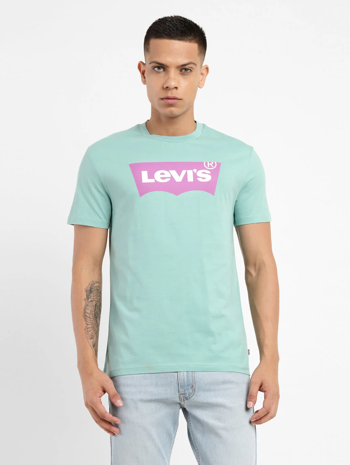


Predicted Brand: levi's

Top 5 Similar Images with the Predicted Brand and Matching Query:

Match 1:
  Name: Levi's Boys' Embellished Batwing T-Shirt


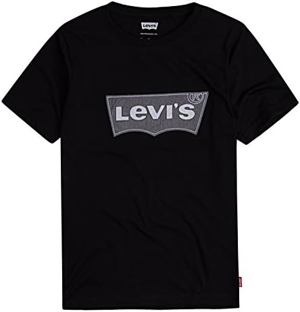


Match 2:
  Name: Levi's Women's Perfect Tee-Shirt (Standard and Plus)


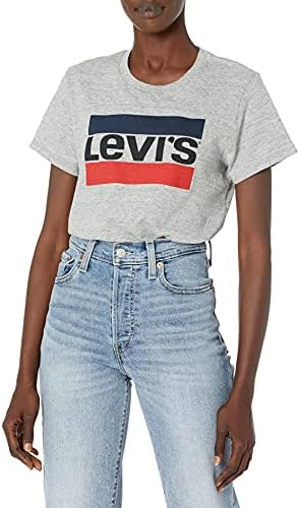


Match 3:
  Name: Levi's Boys' Big Jersey Graphic Tee


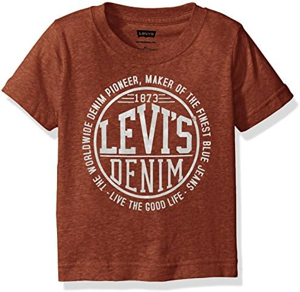


Match 4:
  Name: Levi's Baby Girls' High Rise Batwing T-Shirt-Discontinued


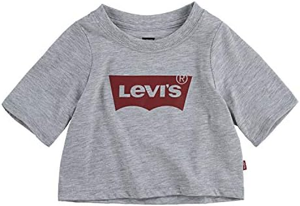


Match 5:
  Name: Levi's Men's Relaxed Graphic Long Sleeve T-Shirt


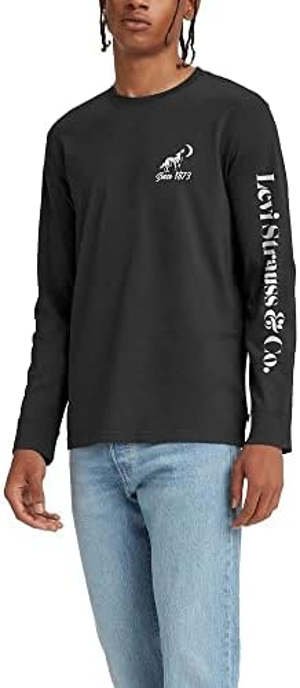

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
from google.colab import files
import requests
from io import BytesIO
import pickle
from IPython.display import display

# Load the CLIP model and processor
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# Predefined brand names for brand prediction
brands = ["nike", "adidas", "puma", "levi's", "jockey", "tommy hilfiger", "louis vuitton", "gucci"]

# Load precomputed embeddings and metadata
pickle_file_path = "/content/drive/My Drive/image_embeddings_amazon_fashion.pkl"
with open(pickle_file_path, "rb") as f:
    data = pickle.load(f)

stored_embeddings = data["embeddings"]
stored_metadata = data["metadata"]

# Helper function to fetch image from URL
def fetch_image_from_url(url):
    try:
        response = requests.get(url)
        response.raise_for_status()
        return Image.open(BytesIO(response.content)).convert("RGB")
    except Exception as e:
        print(f"Error fetching image from URL {url}: {e}")
        return None

# Helper function to display images with a custom width
def display_image_with_width(image, width):
    aspect_ratio = image.height / image.width
    new_height = int(width * aspect_ratio)
    resized_image = image.resize((width, new_height))
    display(resized_image)

# Step 1: Upload the query image
print("Please upload an image file:")
uploaded = files.upload()
query_image_path = list(uploaded.keys())[0]
query_image = Image.open(query_image_path).convert("RGB")

# Input the accompanying text query
query_text = input("Enter text:")

# Step 2: Predict the brand of the query image
# Process the query image with the predefined brand names
inputs = processor(text=brands, images=query_image, return_tensors="pt", padding=True)

# Extract image and text inputs
image_inputs = inputs["pixel_values"]  # For images
text_inputs = inputs["input_ids"]      # For text

# Compute embeddings for the query image and brand names
with torch.no_grad():
    image_embeds = model.get_image_features(pixel_values=image_inputs)
    text_embeds = model.get_text_features(input_ids=text_inputs)

# Convert embeddings to numpy arrays
image_embeds = image_embeds.cpu().numpy()
text_embeds = text_embeds.cpu().numpy()

# Compute similarity to predict the brand
brand_similarities = cosine_similarity(image_embeds, text_embeds)
predicted_brand = brands[brand_similarities.argmax()]

# Display the query image and the predicted brand
print("\nQuery Image:")
display_image_with_width(query_image, width=350)
print(f"\nPredicted Brand: {predicted_brand}")

# Step 3: Combine image and text query for similarity
def compute_combined_query_embedding(image, text):
    inputs = processor(text=text, images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        image_embeds = model.get_image_features(pixel_values=inputs["pixel_values"]).squeeze()
        text_embeds = model.get_text_features(input_ids=inputs["input_ids"]).squeeze()
        # Combine image and text embeddings
        combined_embeds = (image_embeds + text_embeds) / 2  # Average the embeddings
    return combined_embeds.cpu().numpy()

combined_query_embedding = compute_combined_query_embedding(query_image, query_text)

# Compute cosine similarity with stored embeddings
similarities = cosine_similarity([combined_query_embedding], stored_embeddings)[0]

# Sort indices by similarity
sorted_indices = similarities.argsort()[::-1]  # Descending order

# Filter images with the predicted brand
filtered_indices = [
    index for index in sorted_indices
    if stored_metadata[index]['brand'].lower() == predicted_brand.lower()
]

# Get the top 5 similar images with the predicted brand
top_indices = filtered_indices[:5]

# Step 4: Display the top 5 similar images
print("\nTop 5 Similar Images with the Predicted Brand and Matching Query:")
for i, index in enumerate(top_indices):
    meta = stored_metadata[index]
    print(f"\nMatch {i+1}:")
    print(f"  Name: {meta['title']}")
    image_url = meta['image']
    similar_image = fetch_image_from_url(image_url)
    if similar_image:
        display_image_with_width(similar_image, width=300)